In [1]:
import json
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split, StratifiedKFold
from scipy.stats import pointbiserialr
import xgboost as xgb
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
Cards = pd.read_csv("./data/cards_data.csv")
Transactions = pd.read_csv("./data/transactions_data.csv")
Users = pd.read_csv("./data/users_data.csv")

In [3]:
Cards['credit_limit'] = Cards['credit_limit'].replace('[\$,]', '', regex=True).astype(float)
Users['yearly_income'] = Users['yearly_income'].replace('[\$,]', '', regex=True).astype(float)
Users['total_debt'] = Users['total_debt'].replace('[\$,]', '', regex=True).astype(float)
Users['per_capita_income'] = Users['per_capita_income'].replace('[\$,]', '', regex=True).astype(float)
Transactions['amount'] = Transactions['amount'].replace('[\$,]', '', regex=True).astype(float)

# 合併三表
Trans_merge = pd.DataFrame()
Trans_merge = Transactions.merge(Cards, left_on="card_id", right_on="id", suffixes=("_txn","_card"))
Trans_merge = Trans_merge.merge(Users, left_on="client_id_txn", right_on="id", suffixes=("","_user"))

In [4]:
Trans_merge['date'] = pd.to_datetime(Trans_merge['date'])

## 每小時交易量
Trans_merge['hour'] = Trans_merge['date'].dt.floor('H')

hourly_volume = (
    Trans_merge
    .groupby(['client_id_txn', 'hour'])['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'hourly_transaction_volume'})
)

if 'hourly_transaction_volume' in Trans_merge.columns:
    Trans_merge = Trans_merge.drop(columns=['hourly_transaction_volume'])
    
Trans_merge = Trans_merge.merge(
    hourly_volume,
    on=['client_id_txn', 'hour'],
    how='left'
)

In [5]:
with open('./data/train_fraud_labels.json', 'r') as f:
    fraud_data = json.load(f)

fraud_dict = fraud_data['target']

fraud_dict = {int(k): v for k, v in fraud_dict.items()}

Trans_merge['id_txn'] = Trans_merge['id_txn'].astype(int)

Trans_merge['is_fraud'] = Trans_merge['id_txn'].map(fraud_dict)
Trans_merge = Trans_merge[Trans_merge['is_fraud'].notna()].copy()
Trans_merge['is_fraud'] = Trans_merge['is_fraud'].map({'Yes': 1, 'No': 0})

In [6]:
columns_to_drop = ['id_txn', 'client_id_txn', 'card_id', 'merchant_id', 'date']
Trans_merge = Trans_merge.drop(columns=columns_to_drop)

Trans_merge.info()

print(Trans_merge['is_fraud'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 8914963 entries, 0 to 13305912
Data columns (total 37 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   amount                     float64       
 1   use_chip                   object        
 2   merchant_city              object        
 3   merchant_state             object        
 4   zip                        float64       
 5   mcc                        int64         
 6   errors                     object        
 7   id_card                    int64         
 8   client_id_card             int64         
 9   card_brand                 object        
 10  card_type                  object        
 11  card_number                int64         
 12  expires                    object        
 13  cvv                        int64         
 14  has_chip                   object        
 15  num_cards_issued           int64         
 16  credit_limit               float64      

In [7]:
print("--- 原始資料 (Trans_merge) 檢查 ---")
print(f"原始資料形狀: {Trans_merge.shape}")
print("\n原始資料類型 (前 10 欄):")
print(Trans_merge.iloc[:, :10].dtypes)
print("\n原始資料遺失值數量 (前 10 欄):")
print(Trans_merge.iloc[:, :10].isnull().sum())
print("------------------------------------\n")

--- 原始資料 (Trans_merge) 檢查 ---
原始資料形狀: (8914963, 37)

原始資料類型 (前 10 欄):
amount            float64
use_chip           object
merchant_city      object
merchant_state     object
zip               float64
mcc                 int64
errors             object
id_card             int64
client_id_card      int64
card_brand         object
dtype: object

原始資料遺失值數量 (前 10 欄):
amount                  0
use_chip                0
merchant_city           0
merchant_state    1047865
zip               1107377
mcc                     0
errors            8773196
id_card                 0
client_id_card          0
card_brand              0
dtype: int64
------------------------------------



In [8]:
import time
from tqdm import tqdm

tqdm.pandas()

start_time = time.time()

df = Trans_merge.copy()
TARGET_COLUMN = 'is_fraud'

print("==== Step 1: 移除遺失值過高欄位 ====")
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.7].index
print(f"以下欄位遺失超過 70%：{list(cols_to_drop)}")
df.drop(columns=cols_to_drop, inplace=True)
print(f"已移除 {len(cols_to_drop)} 個欄位。\n")

print("==== Step 2: 處理類別特徵與數值轉換 (已修正高基數) ====")

# 1. 識別所有類別欄位
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if not categorical_cols:
    print("未發現非數值欄位，跳過編碼。")
else:
    HIGH_CARDINALITY_THRESHOLD = 50 # 自定義閾值
    low_card_cols = [col for col in categorical_cols if df[col].nunique() <= HIGH_CARDINALITY_THRESHOLD]
    high_card_cols = [col for col in categorical_cols if df[col].nunique() > HIGH_CARDINALITY_THRESHOLD]
    
    # a. 對低基數欄位執行 One-Hot Encoding
    if low_card_cols:
        print(f"  👉 低基數欄位 ({len(low_card_cols)}個): 執行 OHE")
        df = pd.get_dummies(df, columns=low_card_cols, dummy_na=False)
        
    # b. 對高基數欄位執行頻率編碼 (Frequency Encoding)
    if high_card_cols:
        print(f"  👉 高基數欄位 ({len(high_card_cols)}個): 執行頻率編碼 (降維)")
        for col in high_card_cols:
            freq_map = df[col].value_counts(normalize=True).to_dict()
            df[col] = df[col].map(freq_map)
            # 現在這些欄位已經變成數值 (頻率)
            
# 2. 最終數值轉換 (保持原狀，處理潛在的轉換錯誤)
for col in tqdm(df.columns, desc="Final numerical conversion"):
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n=== Step 3: 遺失值填補 (column-by-column SimpleImputer) ===")
cols_to_impute = df.columns[df.isnull().any()]
print(f"需要填補遺失值的欄位數：{len(cols_to_impute)}")

from sklearn.impute import SimpleImputer

for col in cols_to_impute:
    try:
        imputer = SimpleImputer(strategy="median")
        df[[col]] = imputer.fit_transform(df[[col]])
    except Exception as e:
        print(f"⚠️ 欄位 {col} 無法使用 median 填補，改用常數 0。錯誤：{e}")
        df[col] = df[col].fillna(0)
        
print("\n==== Step 4: 數據標準化 ====")
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("RobustScaler 執行中...")
X_robust = pd.DataFrame(RobustScaler().fit_transform(X), columns=X.columns)

print("MinMaxScaler 執行中...")
X_scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_robust), columns=X.columns)

print("➡️ 數據縮放完成\n")


# print("==== Step 5: train-test split (By 10 fold CV) ====")
# skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=34)

# X_train_folds = []
# X_test_folds = []
# y_train_folds = []
# y_test_folds = []

# print(f"{'Fold':<6} | {'Train Count':<12} | {'Test Count':<12}")
# print("-" * 35)

# for i, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y), start=1):
#     X_train_fold = X_scaled.iloc[train_idx]
#     X_test_fold  = X_scaled.iloc[test_idx]
#     y_train_fold = y.iloc[train_idx]
#     y_test_fold  = y.iloc[test_idx]

#     X_train_folds.append(X_train_fold)
#     X_test_folds.append(X_test_fold)
#     y_train_folds.append(y_train_fold)
#     y_test_folds.append(y_test_fold)
    
#     print(f"Fold {i:<2} | {len(train_idx):<12,d} | {len(test_idx):<12,d}")

# print("-" * 35)

# selected_fold_index = 9
# print(f"👉 選擇使用第 {selected_fold_index + 1} 折 (Index {selected_fold_index}) 作為最終 Train/Test")

# X_train = X_train_folds[selected_fold_index]
# X_test  = X_test_folds[selected_fold_index]
# y_train = y_train_folds[selected_fold_index]
# y_test  = y_test_folds[selected_fold_index]

print("==== Step 5: train-test split ====")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=34, stratify=y
)

print(f"訓練集: {len(X_train)}  | 測試集: {len(X_test)}\n")

### 先不做 ASASYN
# print("\n==== Step 6: ADASYN 平衡資料 ====")
# print("⚠️ ADASYN 開始 (如果特徵很多可能很慢)...")
# t0 = time.time()
# adasyn = ADASYN(sampling_strategy='minority', random_state=42, n_neighbors=5)
# X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
# print(f"ADASYN 完成，耗時 {time.time() - t0:.1f} 秒")
# print(f"ADASYN 後資料量: {len(X_train_res)}")
# print(f"舞弊比例: {y_train_res.mean():.4f}")

# print("\n總耗時：", time.time() - start_time, "秒")

==== Step 1: 移除遺失值過高欄位 ====
以下欄位遺失超過 70%：['errors']
已移除 1 個欄位。

==== Step 2: 處理類別特徵與數值轉換 (已修正高基數) ====
  👉 低基數欄位 (6個): 執行 OHE
  👉 高基數欄位 (5個): 執行頻率編碼 (降維)


Final numerical conversion: 100%|██████████████████████████████████████████████████████| 45/45 [00:00<00:00, 79.91it/s]



=== Step 3: 遺失值填補 (column-by-column SimpleImputer) ===
需要填補遺失值的欄位數：2

==== Step 4: 數據標準化 ====
RobustScaler 執行中...
MinMaxScaler 執行中...
➡️ 數據縮放完成

==== Step 5: train-test split ====
訓練集: 6240474  | 測試集: 2674489



In [9]:
# ==== 檢查點 3: 最終訓練數據 (在 Step 6 之後) ====
# 假設最終訓練數據是 X_train 和 y_train
print("--- 最終訓練數據 (X_train, y_train) 檢查 ---")
print(f"最終訓練集形狀: {X_train.shape}")
print(f"目標欄位 {TARGET_COLUMN} 的資料類型: {y_train.dtype}")
print(f"最終舞弊比例 (平均值): {y_train.mean():.4f}")
print("\n特徵 (X_train) 的統計概況 (前 5 欄):")
# 檢查標準化是否成功 (MinMaxScaler 應該讓 Min=0, Max=1)
print(X_train.iloc[:, :5].describe().loc[['min', 'max']])
print("------------------------------------\n")

--- 最終訓練數據 (X_train, y_train) 檢查 ---
最終訓練集形狀: (6240474, 44)
目標欄位 is_fraud 的資料類型: int64
最終舞弊比例 (平均值): 0.0015

特徵 (X_train) 的統計概況 (前 5 欄):
       amount  merchant_city  merchant_state  zip  mcc
min  0.000000            0.0             0.0  0.0  0.0
max  0.871137            1.0             1.0  1.0  1.0
------------------------------------




[Starting to plot Lasso coefficient paths...]
[Starting to plot Ridge coefficient paths...]


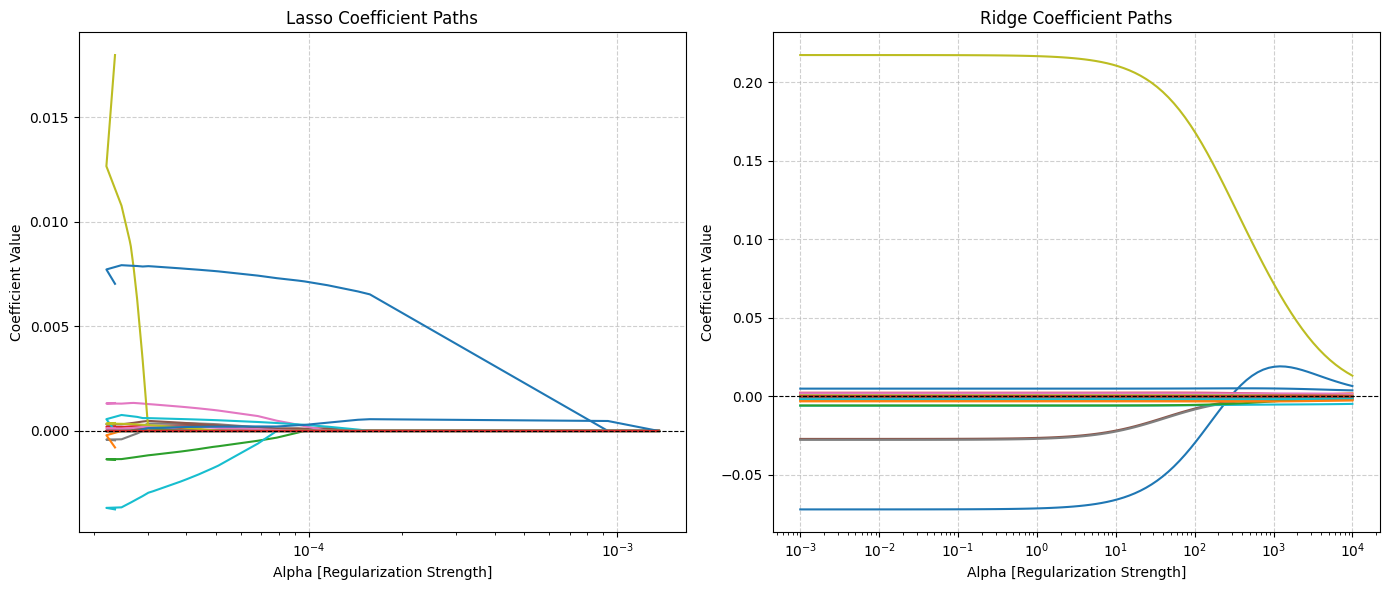

In [10]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lars_path, Ridge
import numpy as np
import pandas as pd

initial_features = X_train.columns.tolist() 
N_FEATURES = len(initial_features)

features_to_plot = initial_features
X_plot = X_train[features_to_plot]
y_plot = y_train

# -----------------------------
# 繪製 Lasso 係數路徑
# -----------------------------
print("\n[Starting to plot Lasso coefficient paths...]")
alphas, active, coefs = lars_path(X_plot.values, y_plot.values, method='lasso', verbose=False)
coefs = coefs.T

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)

# 繪製係數
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=features_to_plot[i])

plt.xscale('log')
plt.xlabel('Alpha [Regularization Strength]')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

# -----------------------------
# 繪製 Ridge 係數路徑
# -----------------------------
print("[Starting to plot Ridge coefficient paths...]")
ridge_alphas = np.logspace(-3, 4, 100)
ridge_coefs = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha, max_iter=10000, random_state=34)
    ridge.fit(X_plot, y_plot)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.subplot(1, 2, 2)

# 繪製係數
for i in range(ridge_coefs.shape[1]):
    plt.plot(ridge_alphas, ridge_coefs[:, i], label=features_to_plot[i])

plt.xscale('log')
plt.xlabel('Alpha [Regularization Strength]')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Paths')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
import xgboost as xgb
from collections import OrderedDict
from sklearn.preprocessing import StandardScaler
# 假設 X_train, y_train, X_test 已經存在

# 1. 初始化特徵名稱
initial_features = X_train.columns.tolist()

# 2. 初始化排名 DataFrame
feature_ranks = pd.DataFrame(index=initial_features)

# 3. 參數設定
ALPHA_VALUES_Lasso = [0.000001, 0.00001, 0.0001, 0.0005, 0.001]
ALPHA_VALUES_Ridge = [100, 1000, 10000, 100000, 1000000]
L_COEFF_THRESHOLD = 1e-4
R_COEFF_THRESHOLD = 0.001
N_TOP_K = min(15, len(initial_features))

# 4. 初始化結果儲存變量
selection_results = {}
final_features = []

# ============================================================
# 1. Baseline：使用全部特徵
# ============================================================
print("=== 1. 使用全部特徵 (Baseline) ===")
print(f"特徵總數：{len(initial_features)}")

# ============================================================
# 2. Lasso 特徵選擇 (多 Alpha) - 主用 Threshold 篩選
# ============================================================
print("\n=== 2. Lasso 特徵選擇（多 Alpha 版）- 主用 Threshold 篩選 ===")
lasso_results = {}

for alpha in tqdm(ALPHA_VALUES_Lasso, desc="Lasso Alpha Selection"):
    print(f"\n--- Lasso (alpha={alpha}) ---")
    
    lasso = Lasso(
        alpha=alpha,
        max_iter=50000,
        tol=1e-3,
        random_state=34
    )
    try:
        lasso.fit(X_train, y_train)
    except Exception as e:
        print(f"Lasso with alpha={alpha} failed: {e}")
        continue

    lasso_coeffs_sorted = (
        pd.Series(lasso.coef_, index=initial_features)
        .abs()
        .sort_values(ascending=False)
    )

    # 🎯 核心：計算並儲存非零係數特徵 (Threshold 篩選)
    lasso_nonzero_series = lasso_coeffs_sorted[lasso_coeffs_sorted > L_COEFF_THRESHOLD]
    lasso_selected_features = lasso_nonzero_series.index.tolist()
    
    # 計算 Top K (用於內部追蹤和儲存)
    lasso_topk = lasso_coeffs_sorted.index[:N_TOP_K].tolist()
    
    lasso_results[alpha] = {
        "coeffs_sorted": lasso_coeffs_sorted,
        "Selected_Features": lasso_selected_features,  # Threshold 結果
        "Top_K_Features": lasso_topk,                  # Top-K 結果
        "NonZero_Count": len(lasso_selected_features)
    }
    
    # 💥 已移除： === 排名追蹤：將 alpha=1e-4 的排名納入 (較好的稀疏性) ===

    print(f"Lasso (Threshold={L_COEFF_THRESHOLD}) 精選特徵數：{len(lasso_selected_features)}")
    # print(f"特徵集合：{lasso_selected_features}") # 避免輸出過長
    
selection_results["Lasso"] = lasso_results


# ============================================================
# 3. Ridge 特徵選擇 (多 Alpha) - 主用 Top-K 排名
# ============================================================
print("\n=== 3. Ridge 特徵選擇（多 Alpha 版）- 主用 Top-K 排名 ===")
ridge_results = {}

for alpha in tqdm(ALPHA_VALUES_Ridge, desc="Ridge Alpha Selection"):
    print(f"\n--- Ridge (alpha={alpha}) ---")
    
    ridge = Ridge(
        alpha=alpha,
        max_iter=50000,
        tol=1e-3,
        random_state=34
    )
    try:
        ridge.fit(X_train, y_train)
    except Exception as e:
        print(f"Ridge with alpha={alpha} failed: {e}")
        continue

    ridge_coeffs_sorted = (
        pd.Series(ridge.coef_, index=initial_features)
        .abs()
        .sort_values(ascending=False)
    )
    
    # 儲存根據閾值精選的特徵 (僅用於追蹤)
    ridge_threshold_features = ridge_coeffs_sorted[ridge_coeffs_sorted > R_COEFF_THRESHOLD].index.tolist()

    # 🎯 核心：Ridge Top K (用於聯集，因為排名穩定)
    ridge_topk = ridge_coeffs_sorted.index[:N_TOP_K].tolist()
    
    # 計算排名 (保留在內部 results 字典中，供內部檢查)
    current_rank = ridge_coeffs_sorted.rank(ascending=False)
    
    ridge_results[alpha] = {
        "coeffs_sorted": ridge_coeffs_sorted,
        "Top_K_Features": ridge_topk,          # Top-K 結果
        "Selected_Features": ridge_threshold_features, # Threshold 結果
        "Rank": current_rank
    }

    # 💥 已移除： === 排名追蹤：將 alpha=10 的排名納入 ===

    print(f"Ridge Top-K ({N_TOP_K}) 特徵數: {len(ridge_topk)}")
    # print(f"Ridge (Threshold={R_COEFF_THRESHOLD}) 精選特徵數: {len(ridge_threshold_features)}")

selection_results["Ridge"] = ridge_results

# ============================================================

# 🎯 3.5. 存儲每個 Alpha 的精選特徵到單獨變數

# ============================================================

print("\n=== 3.5. 儲存單獨 Alpha 特徵集變數 ===")
def format_var_name_simple(alpha):
    # 這裡假設您的 alpha 轉換是正確的，例如 0.0001 -> '0_0001' 或 10000 -> '10000'
    return str(alpha).replace('.', '_')  

# 1. 處理 Lasso Threshold 特徵集 (用於真正的稀疏性篩選)
for alpha, result in lasso_results.items():
    var_name = f"lasso_nonzero_{format_var_name_simple(alpha)}"  # 新的命名
    globals()[var_name] = result['Selected_Features']
    print(f"已儲存 Lasso NonZero 特徵集至: {var_name} ({len(result['Selected_Features'])}個特徵)")

# 2. 處理 Ridge Top-K 特徵集 (用於最佳排名子集)
for alpha, result in ridge_results.items():
    var_name = f"ridge_topk_{format_var_name_simple(alpha)}"    # 沿用 Top-K 的命名
    globals()[var_name] = result['Top_K_Features']
    print(f"已儲存 Ridge Top-K 特徵集至: {var_name} ({len(result['Top_K_Features'])}個特徵)")

    
TOP_K_COUNT = 10
# ============================================================
# 4. XGBOOST（非線性特徵重要度）
# ============================================================
print("\n=== 4. XGBoost 特徵選擇 (Top 10) ===")

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=34, # 使用 random_state=34
    n_jobs=-1,
    tree_method="hist",
    enable_categorical=False
)
xgb_model.fit(X_train, y_train)

raw_importance = xgb_model.get_booster().get_score(importance_type="gain")
mapped_importance = pd.Series(0, index=initial_features)

for key, val in raw_importance.items():
    col_name = key
    if key.startswith("f") and key[1:].isdigit():
        idx = int(key[1:])
        if idx < len(initial_features):
            col_name = initial_features[idx]
        else:
            continue
    
    if col_name in mapped_importance.index:
        mapped_importance[col_name] = val

importance_sorted = mapped_importance.sort_values(ascending=False)

# === 排名追蹤：加入 XGBoost 的排名 (保持原樣) ===
feature_ranks["XGBoost_Rank"] = importance_sorted.rank(ascending=False)

# 🎯 輸出變數：xgb_topk_10
xgb_topk_10 = importance_sorted.index[:TOP_K_COUNT].tolist() # 使用 TOP_K_COUNT (例如 10)
globals()['xgb_topk_10'] = xgb_topk_10 # 💥 新增：儲存到 globals()

xgb_selected = importance_sorted[importance_sorted > 0].index.tolist()

xgb_results = {
    "Top_K_Features": xgb_topk_10, # 使用新的 Top 10 列表
    "Importance_Series": importance_sorted
}
selection_results["XGBoost"] = xgb_results

print(f"XGBoost 重要性>0 的特徵數：{len(xgb_selected)}")
print(f"XGBoost Top {TOP_K_COUNT} (xgb_topk_10)：{xgb_topk_10}")


# ============================================================
# 5. 三模型 TOP-K 聯集 (Top 10)
# ============================================================
print("\n=== 5. 三種方法 Top-K 聯集 (Top 10) ===")

# 決策：使用 Lasso_0_001 和 Ridge_10 的特徵集 (假設它們也是 Top N_TOP_K)
lasso_topk_final = globals().get('lasso_topk_0_001', [])
ridge_topk_final = globals().get('ridge_topk_10', [])

if not lasso_topk_final:
    print("Warning: 變數 lasso_topk_0_001 不存在或為空，將嘗試使用 lasso_results[0.001]。")
    lasso_topk_final = lasso_results.get(0.001, {}).get("Top_K_Features", [])

if not ridge_topk_final:
    print("Warning: 變數 ridge_topk_10 不存在或為空，將嘗試使用 ridge_results[10]。")
    ridge_topk_final = ridge_results.get(10, {}).get("Top_K_Features", [])


# 將這三個 Top-K 特徵按原排序依次加入聯集（保持 Top 重要性）
combine_topk_10 = [] # 🎯 輸出變數：combine_topk_10
seen = set()

# 使用選定的 Lasso, Ridge 結果和 XGBoost Top 10
for feat_list in [lasso_topk_final, 
                  ridge_topk_final, 
                  xgb_topk_10]: # <--- 使用新的 xgb_topk_10
    for f in feat_list:
        if f not in seen:
            combine_topk_10.append(f)
            seen.add(f)

globals()['combine_topk_10'] = combine_topk_10 # 💥 新增：儲存到 globals()

print(f"三模型 Top K 聯集 (combine_topk_10) → 共 {len(combine_topk_10)} 個特徵")
print(f"聯集前 10: {combine_topk_10[:10]}")


# ============================================================
# 6. 最終 XGBoost Top 10 精選 (在聯集特徵上重新訓練)
# ============================================================
print("\n=== 6. 最終 XGBoost Top 10 精選 ===")

if not combine_topk_10: # <--- 使用新的聯集變數
    print("無法進行最終精選：聯集特徵列表為空。")
    final_top_10 = []
else:
    X_combined = X_train[combine_topk_10]
    xgb_model_final = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        enable_categorical=False
    )
    xgb_model_final.fit(X_combined, y_train)

    final_raw_importance = xgb_model_final.get_booster().get_score(importance_type="gain")
    mapped_final = pd.Series(0, index=combine_topk_10)

    # --- 安全 mapping ---
    for key, val in final_raw_importance.items():
        col_name = key
        if key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(combine_topk_10):
                col_name = combine_topk_10[idx]
            else:
                continue
        
        if col_name in mapped_final.index:
            mapped_final[col_name] = val

    sorted_final = mapped_final.sort_values(ascending=False)
    final_top_10 = sorted_final.index[:TOP_K_COUNT].tolist() # 🎯 輸出變數：final_top_10
    globals()['final_top_10'] = final_top_10 # 💥 新增：儲存到 globals()

    print(f"\n🎯 最終精選的 Top {TOP_K_COUNT} 特徵 (final_top_10)：")
    print(final_top_10)

print("\n=== 特徵選擇完成 ===")

=== 1. 使用全部特徵 (Baseline) ===
特徵總數：44

=== 2. Lasso 特徵選擇（多 Alpha 版）- 主用 Threshold 篩選 ===


Lasso Alpha Selection:   0%|                                                                     | 0/5 [00:00<?, ?it/s]


--- Lasso (alpha=1e-06) ---


Lasso Alpha Selection:  20%|████████████                                                | 1/5 [03:02<12:11, 182.97s/it]

Lasso (Threshold=0.0001) 精選特徵數：24

--- Lasso (alpha=1e-05) ---


...

Ridge Alpha Selection:  80%|████████████████████████████████████████████████▊            | 4/5 [00:05<00:01,  1.50s/it]

Ridge Top-K (15) 特徵數: 15

--- Ridge (alpha=1000000) ---


Ridge Alpha Selection: 100%|█████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.50s/it]

Ridge Top-K (15) 特徵數: 15

=== 3.5. 儲存單獨 Alpha 特徵集變數 ===
已儲存 Lasso NonZero 特徵集至: lasso_nonzero_1e-06 (24個特徵)
已儲存 Lasso NonZero 特徵集至: lasso_nonzero_1e-05 (15個特徵)
已儲存 Lasso NonZero 特徵集至: lasso_nonzero_0_0001 (4個特徵)
已儲存 Lasso NonZero 特徵集至: lasso_nonzero_0_0005 (1個特徵)
已儲存 Lasso NonZero 特徵集至: lasso_nonzero_0_001 (0個特徵)
已儲存 Ridge Top-K 特徵集至: ridge_topk_100 (15個特徵)
已儲存 Ridge Top-K 特徵集至: ridge_topk_1000 (15個特徵)
已儲存 Ridge Top-K 特徵集至: ridge_topk_10000 (15個特徵)
已儲存 Ridge Top-K 特徵集至: ridge_topk_100000 (15個特徵)
已儲存 Ridge Top-K 特徵集至: ridge_topk_1000000 (15個特徵)

=== 4. XGBoost 特徵選擇 (Top 10) ===


XGBoost 重要性>0 的特徵數：38
XGBoost Top 10 (xgb_topk_10)：['credit_limit', 'merchant_city', 'merchant_state', 'amount', 'latitude', 'zip', 'hour', 'hourly_transaction_volume', 'credit_score', 'current_age']

=== 5. 三種方法 Top-K 聯集 (Top 10) ===
三模型 Top K 聯集 (combine_topk_10) → 共 20 個特徵
聯集前 10: ['amount', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'id_card', 'client_id_card', 'card_number', 'expires', 'cvv']

=== 6. 最終 XGBoost Top 10 精選 ===

🎯 最終精選的 Top 10 特徵 (final_top_10)：
['credit_limit', 'merchant_state', 'merchant_city', 'hour', 'amount', 'latitude', 'zip', 'hourly_transaction_volume', 'mcc', 'current_age']

=== 特徵選擇完成 ===


In [12]:
import pandas as pd
import numpy as np
from collections import OrderedDict

# 引入 cross_validate
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import xgboost as xgb
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, average_precision_score, accuracy_score
)

feature_sets_raw = OrderedDict({
    # --- 基準線 ---
    "Full_Set_Baseline": globals().get('initial_features', []),
    
    # --- Lasso 特徵集 (L1) --- 
    "Lasso (a=1e-6)": globals().get('lasso_nonzero_1e-06', []), 
    "Lasso (a=1e-5)": globals().get('lasso_nonzero_1e-05', []), 
    "Lasso (a=1e-4)": globals().get('lasso_nonzero_0_0001', []), 
    "Lasso (a=1e-3)": globals().get('lasso_nonzero_0_001', []),
    
    # --- Ridge 特徵集 (L2) ---
    "Ridge (a=1e2)": globals().get('ridge_topk_100', []),
    "Ridge (a=1e3)": globals().get('ridge_topk_1000', []),
    "Ridge (a=1e4)": globals().get('ridge_topk_10000', []),
    "Ridge (a=1e5)": globals().get('ridge_topk_100000', []),
    "Ridge (a=1e6)": globals().get('ridge_topk_1000000', []),
    
    # --- 非線性與組合特徵集 ---
    "XGBoost_Top10": globals().get('xgb_topk_10', []),
    # "Union_Top10": globals().get('combine_topk_10', []),
})

models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=34),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="auc", random_state=34,
        n_jobs=-1, use_label_encoder=False, tree_method="hist",
        n_estimators=100, max_depth=6
    )
}

# ----------------------------------------------------------------------
# 📌 步驟 1: 特徵集與模型準備
# ----------------------------------------------------------------------
# (假設 feature_sets_raw 已經定義好，這邊直接過濾)
feature_sets = OrderedDict()
for key, value in feature_sets_raw.items():
    if isinstance(value, list) and len(value) > 0:
        feature_sets[key] = value

# ----------------------------------------------------------------------
# 📌 步驟 2: 設定 CV 的評分標準
# ----------------------------------------------------------------------
# 這裡定義我們要在 CV 中計算的所有指標
# 注意: 'average_precision' 是 sklearn 中用來計算 PR-AUC 的標準指標名稱
scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'auc': 'roc_auc',
    'pr_auc': 'average_precision' 
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
run_idx = 0
total_runs = len(feature_sets) * len(models)

print(f"🚀 開始執行，Train 指標將採用 5-Fold CV 平均值...")

# ----------------------------------------------------------------------
# 📌 步驟 3: 雙重迴圈
# ----------------------------------------------------------------------
for fs_name, fs_cols in feature_sets.items():
    
    # 防呆：確保欄位存在
    try:
        X_train_fs = X_train[fs_cols]
        X_test_fs = X_test[fs_cols]
    except KeyError:
        continue

    for model_name, model in models.items():
        run_idx += 1
        
        # QDA 限制跳過
        if model_name == "QDA" and (len(fs_cols) >= X_train_fs.shape[0] or len(fs_cols) <= 1):
            continue

        print(f"[{run_idx}/{total_runs}] {fs_name} + {model_name}")

        try:
            # ==========================================================
            # 1️⃣ Part A: Cross-Validation (計算 Train 的 5-Fold 平均)
            # ==========================================================
            # cross_validate 可以一次算出所有指標
            # 注意: sklearn 回傳的 key 叫做 'test_f1', 'test_auc' 等，這裡的 'test' 指的是 Validation Fold
            cv_results = cross_validate(
                model, X_train_fs, y_train, 
                cv=cv_strategy, 
                scoring=scoring_metrics,
                n_jobs=-1
            )

            # 取平均值 (這就是你要的 "Train" 指標)
            train_accuracy  = cv_results['test_accuracy'].mean()
            train_f1        = cv_results['test_f1'].mean()
            train_precision = cv_results['test_precision'].mean()
            train_recall    = cv_results['test_recall'].mean()
            train_auc       = cv_results['test_auc'].mean()
            train_pr_auc    = cv_results['test_pr_auc'].mean()

            # ==========================================================
            # 2️⃣ Part B: Final Test (真正的期末考)
            # ==========================================================
            # 重新用全部資料訓練一次
            model.fit(X_train_fs, y_train)
            
            # 預測
            y_test_pred = model.predict(X_test_fs)
            
            # 取得機率 (為了算 AUC / PR-AUC)
            if hasattr(model, "predict_proba"):
                y_test_prob = model.predict_proba(X_test_fs)[:, 1]
            else:
                y_test_prob = model.decision_function(X_test_fs)

            # 計算測試集指標
            test_accuracy  = accuracy_score(y_test, y_test_pred)
            test_f1        = f1_score(y_test, y_test_pred)
            test_precision = precision_score(y_test, y_test_pred, zero_division=0)
            test_recall    = recall_score(y_test, y_test_pred, zero_division=0)
            test_auc       = roc_auc_score(y_test, y_test_prob)
            test_pr_auc    = average_precision_score(y_test, y_test_prob)

            # ==========================================================
            # 3️⃣ 儲存結果
            # ==========================================================
            results.append({
                "Feature_Selection": fs_name,
                "Model": model_name,
                "Features_Count": len(fs_cols),
                
                # --- Train (CV Average) ---
                "train_accuracy": train_accuracy,
                "train_f1": train_f1,
                "train_precision": train_precision,
                "train_recall": train_recall,
                "train_auc": train_auc,
                "train_pr_auc": train_pr_auc,
                
                # --- Test (Real Test) ---
                "test_accuracy": test_accuracy,
                "test_f1": test_f1,
                "test_precision": test_precision,
                "test_recall": test_recall,
                "test_auc": test_auc,
                "test_pr_auc": test_pr_auc,
            })

        except Exception as e:
            print(f"  ❌ Error: {e}")

🚀 開始執行，Train 指標將採用 5-Fold CV 平均值...
[1/40] Full_Set_Baseline + LogisticRegression
[2/40] Full_Set_Baseline + LDA
  ❌ Error: [WinError 1450] 系統資源不足，無法完成要求的服務。
[3/40] Full_Set_Baseline + QDA
[4/40] Full_Set_Baseline + XGBoost
[5/40] Lasso (a=1e-6) + LogisticRegression
[6/40] Lasso (a=1e-6) + LDA
[7/40] Lasso (a=1e-6) + QDA
[8/40] Lasso (a=1e-6) + XGBoost
[9/40] Lasso (a=1e-5) + LogisticRegression
[10/40] Lasso (a=1e-5) + LDA
[11/40] Lasso (a=1e-5) + QDA
[12/40] Lasso (a=1e-5) + XGBoost
[13/40] Lasso (a=1e-4) + LogisticRegression
[14/40] Lasso (a=1e-4) + LDA
[15/40] Lasso (a=1e-4) + QDA
[16/40] Lasso (a=1e-4) + XGBoost
[17/40] Ridge (a=1e2) + LogisticRegression
[18/40] Ridge (a=1e2) + LDA
[19/40] Ridge (a=1e2) + QDA
[20/40] Ridge (a=1e2) + XGBoost
[21/40] Ridge (a=1e3) + LogisticRegression
[22/40] Ridge (a=1e3) + LDA
[23/40] Ridge (a=1e3) + QDA
[24/40] Ridge (a=1e3) + XGBoost
[25/40] Ridge (a=1e4) + LogisticRegression
[26/40] Ridge (a=1e4) + LDA
[27/40] Ridge (a=1e4) + QDA
[28/40] Ridge (

In [13]:
# ----------------------------------------------------------------------
# 📌 步驟 4: 結果整理與輸出
# ----------------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="train_f1", ascending=False)

print("\n### 模型組合性能排序 (依 Cross-Validation F1 排序)")
print("注意：排序依據是 train_f1 (5-Fold CV 驗證集平均表現)，這能防止對測試集 Overfitting。")

cols_to_show = [
    "Feature_Selection", 
    "Model",
    "train_auc", 
    "train_pr_auc", 
    "train_precision", 
    "train_recall", 
    "train_f1",
    "train_accuracy",
    "test_auc", 
    "test_pr_auc", 
    "test_precision", 
    "test_recall", 
    "test_f1",
    "test_accuracy",
]

print(results_df[cols_to_show].to_markdown(index=False, floatfmt=".4f"))


### 模型組合性能排序 (依 Cross-Validation F1 排序)
注意：排序依據是 train_f1 (5-Fold CV 驗證集平均表現)，這能防止對測試集 Overfitting。
| Feature_Selection   | Model              |   train_auc |   train_pr_auc |   train_precision |   train_recall |   train_f1 |   train_accuracy |   test_auc |   test_pr_auc |   test_precision |   test_recall |   test_f1 |   test_accuracy |
|:--------------------|:-------------------|------------:|---------------:|------------------:|---------------:|-----------:|-----------------:|-----------:|--------------:|-----------------:|--------------:|----------:|----------------:|
| Full_Set_Baseline   | XGBoost            |      0.9380 |         0.7426 |            0.8552 |         0.6950 |     0.7667 |           0.9994 |     0.9090 |        0.6729 |           0.8285 |        0.6690 |    0.7402 |          0.9993 |
| Lasso (a=1e-6)      | XGBoost            |      0.9363 |         0.7349 |            0.8508 |         0.6973 |     0.7664 |           0.9994 |     0.9130 |        0.6860 |         

In [ ]:
# ----------------------------------------------------------------------
# 📌 步驟 5: 輸出 Result CSV (自動命名)
# ----------------------------------------------------------------------
import os

if results:
    df_results = pd.DataFrame(results)

    # 確保欄位順序與你要求的範例一致
    column_order = [
        "Feature_Selection", "Model",
        "train_auc", "train_pr_auc", "train_precision", "train_recall", "train_f1", "train_accuracy",
        "test_auc", "test_pr_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"
    ]
    # 只選取存在的欄位 (防呆)
    final_cols = [c for c in column_order if c in df_results.columns]
    df_results = df_results[final_cols]

    # 設定基本檔名
    base_filename = "result.csv"
    output_filename = base_filename
    counter = 1

    # 檢查檔案是否存在，若存在則加上編號 (01, 02, ...)
    while os.path.exists(output_filename):
        output_filename = f"result{counter:02d}.csv"
        counter += 1

    # 存檔 (float_format 設定小數點後 4 位)
    df_results.to_csv(output_filename, index=False, float_format='%.4f')
    print(f"\n✅ 運算完成！結果已儲存為: {output_filename}")
    print(df_results.head())

else:
    print("\n⚠️ 運算結束，但沒有產生任何結果。")